# Khám Phá & Trực Quan Hóa Dữ Liệu (Exploratory Data Analysis)

Notebook này tổng hợp quá trình phân tích dữ liệu (EDA), phân bố nhãn, các kỹ thuật Data Augmentation, và toàn bộ các kỹ thuật trích xuất đặc trưng truyền thống và hiện đại nhất để phân biệt ảnh thật (Real) và ảnh giả mạo (Spoof).

In [61]:
from PIL import Image
from collections import Counter
from pathlib import Path
from skimage import exposure
from skimage.feature import local_binary_pattern, hog
from torchvision import datasets
from utils.transforms import InputTransforms
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import torch
import torchvision.transforms.functional as TF

# Nạp utils tự định nghĩa của hệ thống
import sys
sys.path.append(os.getcwd())
from utils.transforms import InputTransforms


---
## 1. Khởi tạo và Phân bố Dữ liệu


In [62]:
# Xác định đường dẫn từ thư mục notebooks/ trỏ ra ngoài
data_dir = "../datasets/LCC_FASD/train"

# Tải dataset nguyên bản
train_dataset = datasets.ImageFolder(root=data_dir)

# Trích xuất danh sách các nhãn (thường là tên thư mục con, vd: 'real', 'spoof')
class_names = train_dataset.classes
print(f"✅ Các nhãn có trong tập dữ liệu: {class_names}")
print(f"✅ Tổng số ảnh trong tập train: {len(train_dataset)}")

# Đoạn mã nhỏ để đếm số lượng ảnh của mỗi nhãn (giúp bạn thấy rõ độ lệch nhãn)
class_counts = {class_name: 0 for class_name in class_names}
for _, label_idx in train_dataset.samples:
    class_name = class_names[label_idx]
    class_counts[class_name] += 1

print(f"📊 Phân bố dữ liệu cụ thể: {class_counts}")

✅ Các nhãn có trong tập dữ liệu: ['real', 'spoof']
✅ Tổng số ảnh trong tập train: 8299
📊 Phân bố dữ liệu cụ thể: {'real': 1223, 'spoof': 7076}


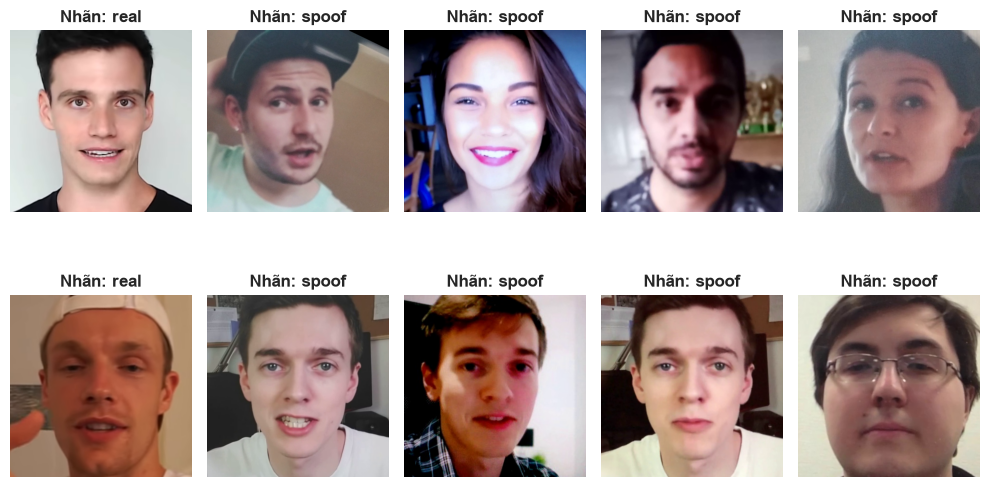

In [63]:
# Tạo một figure chứa lưới 2 hàng, 5 cột. figsize để chỉnh tỷ lệ khung hình
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))

# Lấy ngẫu nhiên 10 chỉ số (index) từ tổng số ảnh
random_indices = random.sample(range(len(train_dataset)), 10)

for i, idx in enumerate(random_indices):
    # Lấy ảnh và chỉ số nhãn tương ứng
    img, label_idx = train_dataset[idx]
    label_name = class_names[label_idx]
    
    # Tính toán tọa độ hàng và cột trên lưới (grid)
    row = i // 5
    col = i % 5
    
    # Hiển thị ảnh
    axes[row, col].imshow(img)
    # Ghi chú tên nhãn ở trên cùng mỗi ảnh
    axes[row, col].set_title(f"Nhãn: {label_name}", fontsize=12, fontweight='bold')
    # Ẩn trục tọa độ x, y để hình nhìn gọn gàng hơn
    axes[row, col].axis('off')

# Tự động căn chỉnh khoảng cách giữa các khung hình để không bị đè chữ
plt.tight_layout()
plt.show()

---
## 2. Phân tích Nhãn (Class Imbalance)


Tỉ lệ lệch nhãn (Class Imbalance) trong tập Train: {'real': '14.74%', 'spoof': '85.26%'}


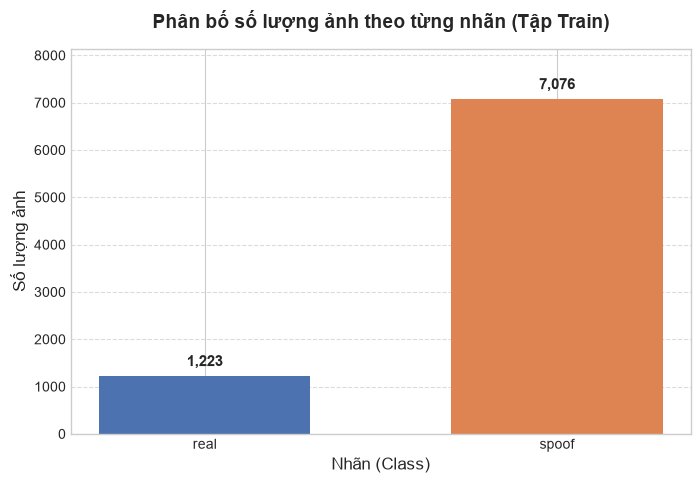

In [64]:
# Tách tên nhãn và số lượng tương ứng thành 2 danh sách
labels = list(class_counts.keys())
counts = list(class_counts.values())

print("Tỉ lệ lệch nhãn (Class Imbalance) trong tập Train:", {label: f"{count / len(train_dataset) * 100:.2f}%" for label, count in class_counts.items()})

# Thiết lập kích thước khung hình
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ cột với màu sắc phân biệt (ví dụ: xanh và cam)
bars = plt.bar(labels, counts, color=['#4C72B0', '#DD8452'], width=0.6)

# Tiêu đề và nhãn trục
plt.title('Phân bố số lượng ảnh theo từng nhãn (Tập Train)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhãn (Class)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)

# Ghi chú số liệu cụ thể lên đỉnh mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.02), 
             f"{int(yval):,}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Tăng không gian trục Y thêm 15% để số liệu trên cột không bị lẹm vào viền trên
plt.ylim(0, max(counts) * 1.15) 

# Thêm lưới ngang để dễ gióng số liệu
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.show()

Tập dữ liệu huấn luyện đang bị mất cân bằng nhãn trầm trọng khi số lượng ảnh giả mạo (spoof) áp đảo gấp gần 6 lần ảnh thật (real), đòi hỏi quy trình huấn luyện phải tích hợp các kỹ thuật cân bằng dữ liệu như `WeightedRandomSampler` hoặc sử dụng hàm mất mát `Focal Loss` để ngăn chặn mô hình học thiên lệch.

---
## 3. Kỹ thuật Tiền xử lý (Data Augmentation)


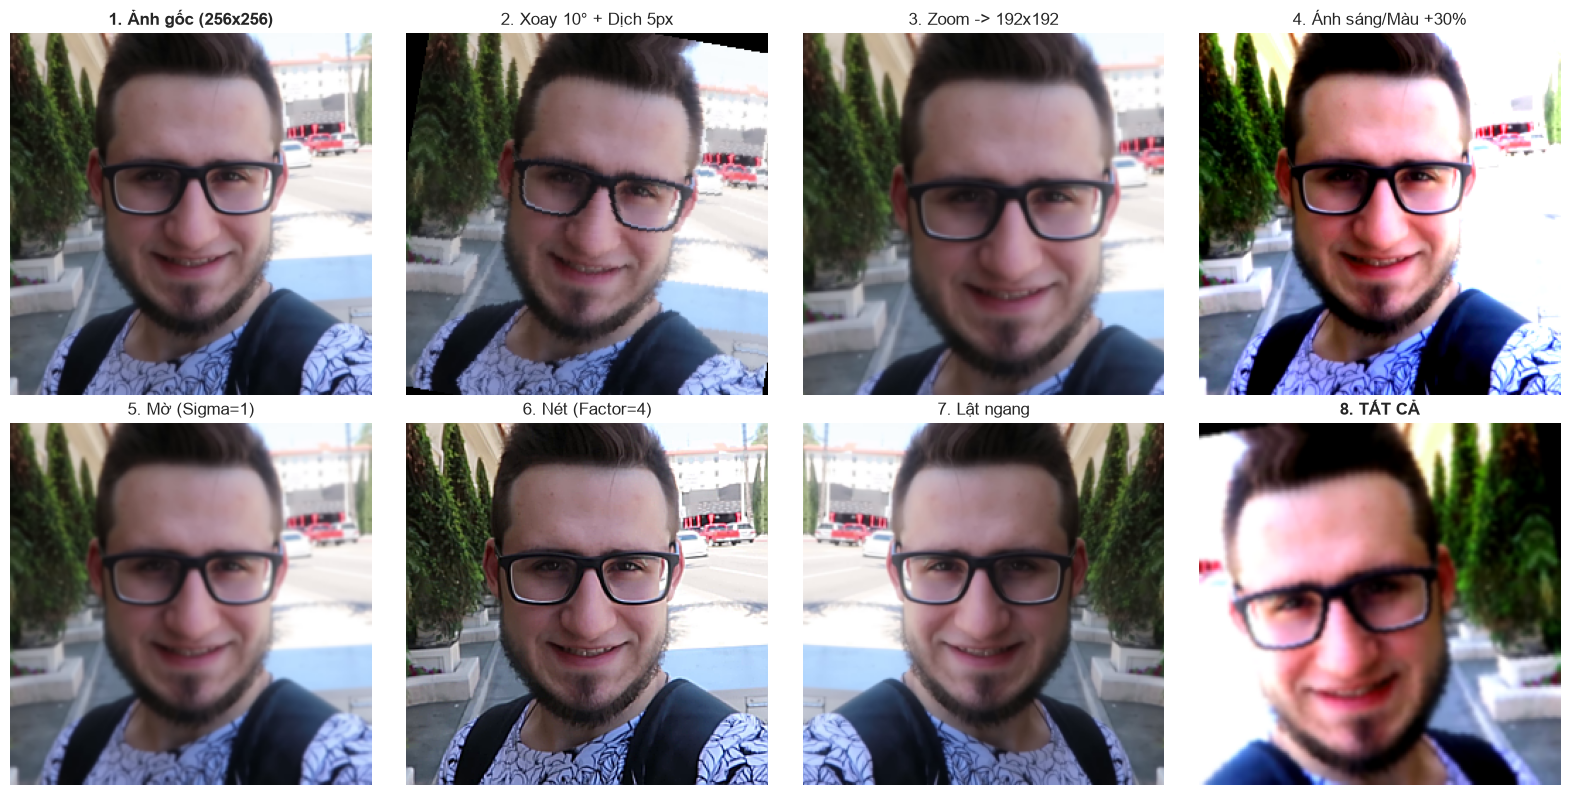

In [65]:
def visualize_report_aug(img):
    """Mã dùng để vẽ hình báo cáo: Cố tình giữ phép xoay để thấy lỗi"""
    img_base = TF.resize(img, (256, 256))
    
    # 2. Xoay 10 độ & Dịch 5px (Tạo viền đen/phản chiếu lỗi để làm báo cáo)
    img_pad = TF.pad(img_base, padding=10, padding_mode='reflect')
    img_affine = TF.affine(img_pad, angle=10, translate=(5, 5), scale=1.0, shear=0)
    img_affine = TF.center_crop(img_affine, 256)
    
    # 3. Zoom & Cắt (Cắt khung 224x224, ép về 192x192)
    img_crop = TF.resized_crop(img_base, top=0, left=0, height=224, width=224, size=(192, 192))
    
    # 4. Ánh sáng & Màu sắc (Tăng 30%)
    img_color = TF.adjust_brightness(img_base, 1.30)
    img_color = TF.adjust_contrast(img_color, 1.30)
    img_color = TF.adjust_saturation(img_color, 1.30)
    img_color = TF.adjust_hue(img_color, 0.02)
    
    # 5. Làm mờ nhẹ
    img_blur = TF.gaussian_blur(img_base, kernel_size=[3, 3], sigma=[1.0])
    
    # 6. Tăng sắc nét (Hệ số 4)
    img_sharp = TF.adjust_sharpness(img_base, sharpness_factor=4.0)
    
    # 7. Lật ngang
    img_flip = TF.hflip(img_base)
    
    # 8. TẤT CẢ KẾT HỢP (Kịch bản xấu nhất có chứa lỗi xoay)
    img_all = TF.affine(TF.pad(img_base, padding=10, padding_mode='reflect'), angle=10, translate=(5, 5), scale=1.0, shear=0)
    img_all = TF.center_crop(img_all, 256)
    img_all = TF.resized_crop(img_all, top=0, left=0, height=224, width=224, size=(192, 192))
    img_all = TF.adjust_brightness(img_all, 1.30)
    img_all = TF.adjust_contrast(img_all, 1.30)
    img_all = TF.adjust_saturation(img_all, 1.30)
    img_all = TF.adjust_hue(img_all, 0.02)
    img_all = TF.gaussian_blur(img_all, kernel_size=[3, 3], sigma=[1.0])
    img_all = TF.hflip(img_all)
    
    # Trực quan hóa lên lưới 2x4
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
    
    axes[0, 0].imshow(img_base); axes[0, 0].set_title("1. Ảnh gốc (256x256)", fontweight='bold')
    axes[0, 1].imshow(img_affine); axes[0, 1].set_title("2. Xoay 10° + Dịch 5px")
    axes[0, 2].imshow(img_crop); axes[0, 2].set_title("3. Zoom -> 192x192")
    axes[0, 3].imshow(img_color); axes[0, 3].set_title("4. Ánh sáng/Màu +30%")
    
    axes[1, 0].imshow(img_blur); axes[1, 0].set_title("5. Mờ (Sigma=1)")
    axes[1, 1].imshow(img_sharp); axes[1, 1].set_title("6. Nét (Factor=4)")
    axes[1, 2].imshow(img_flip); axes[1, 2].set_title("7. Lật ngang")
    axes[1, 3].imshow(img_all); axes[1, 3].set_title("8. TẤT CẢ", fontweight='bold')
    
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Đọc ngẫu nhiên 1 ảnh Real để test
real_dir = "../datasets/LCC_FASD/train/real"
real_images = [f for f in os.listdir(real_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
sample_img_name = random.choice(real_images)
img_path = os.path.join(real_dir, sample_img_name)
original_img = Image.open(img_path).convert('RGB')

visualize_report_aug(original_img)

In [66]:
# Thư viện xử lý ảnh chuẩn mực

# Nạp utils tự định nghĩa của hệ thống

plt.style.use('seaborn-v0_8-whitegrid')

# Tải Dataset


def get_random_samples(dataset, class_name, num_samples=1):
    class_idx = dataset.class_to_idx[class_name]
    indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
    sampled = random.sample(indices, num_samples)
    return [dataset[i][0] for i in sampled]

---
## 4. Trích Xuất Đặc Trưng (Feature Extraction)


---
### 4.1. Phân Tích Đa Không Gian Màu (Multi-Color Space Analysis)

Nhiều đặc trưng rò rỉ ánh sáng từ màn hình điện thoại (Spoof) không hiển thị rõ trên dải RGB. Việc phân rã ra các hệ màu độc lập như độ sáng (Y, V), màu sắc (H), đỏ/xanh (Cr, Cb) giúp dễ dàng bắt được các vệt nhiễu màu này.

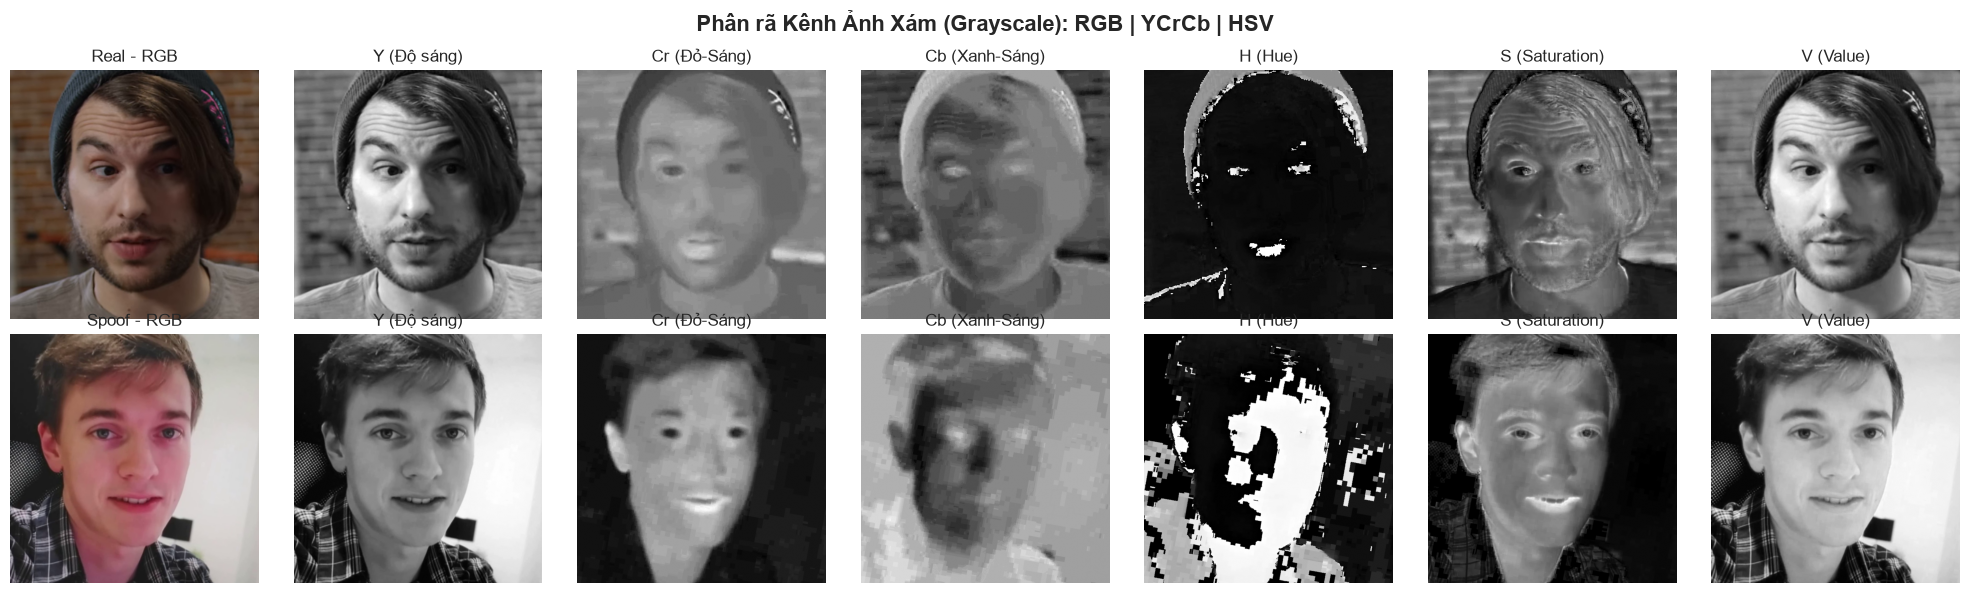

In [67]:
real_img = get_random_samples(train_dataset, 'real', 1)[0]
spoof_img = get_random_samples(train_dataset, 'spoof', 1)[0]
samples = [('Real', real_img), ('Spoof', spoof_img)]

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle("Phân rã Kênh Ảnh Xám (Grayscale): RGB | YCrCb | HSV", fontsize=16, fontweight='bold')

for i, (label, img_pil) in enumerate(samples):
    img_np = np.array(img_pil)
    Y, Cr, Cb = cv2.split(cv2.cvtColor(img_np, cv2.COLOR_RGB2YCrCb))
    H, S, V = cv2.split(cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV))
    
    plots = [
        (img_np, f"{label} - RGB", None),
        (Y, "Y (Độ sáng)", 'gray'), (Cr, "Cr (Đỏ-Sáng)", 'gray'), (Cb, "Cb (Xanh-Sáng)", 'gray'),
        (H, "H (Hue)", 'gray'), (S, "S (Saturation)", 'gray'), (V, "V (Value)", 'gray')
    ]
    
    for j, (img, title, cmap) in enumerate(plots):
        if cmap: axes[i, j].imshow(img, cmap=cmap)
        else: axes[i, j].imshow(img)
        axes[i, j].set_title(title)
        axes[i, j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

---
### 4.2. Trích Xuất Vi Kết Cấu (Micro-Texture & Structure)

Các bề mặt in ấn hay màn hình led đều có kết cấu rỗ, sắc cạnh khác biệt hoàn toàn với da người.
- **LBP (Local Binary Pattern):** Nhìn cấu trúc rỗ siêu nhỏ.
- **DoG (Difference of Gaussians):** Làm rõ nét cạnh viền và cấu trúc khối.
- **HOG (Histogram of Oriented Gradients):** Nhìn tổng thể cấu trúc hình học xem có góc cạnh nhân tạo nào không.

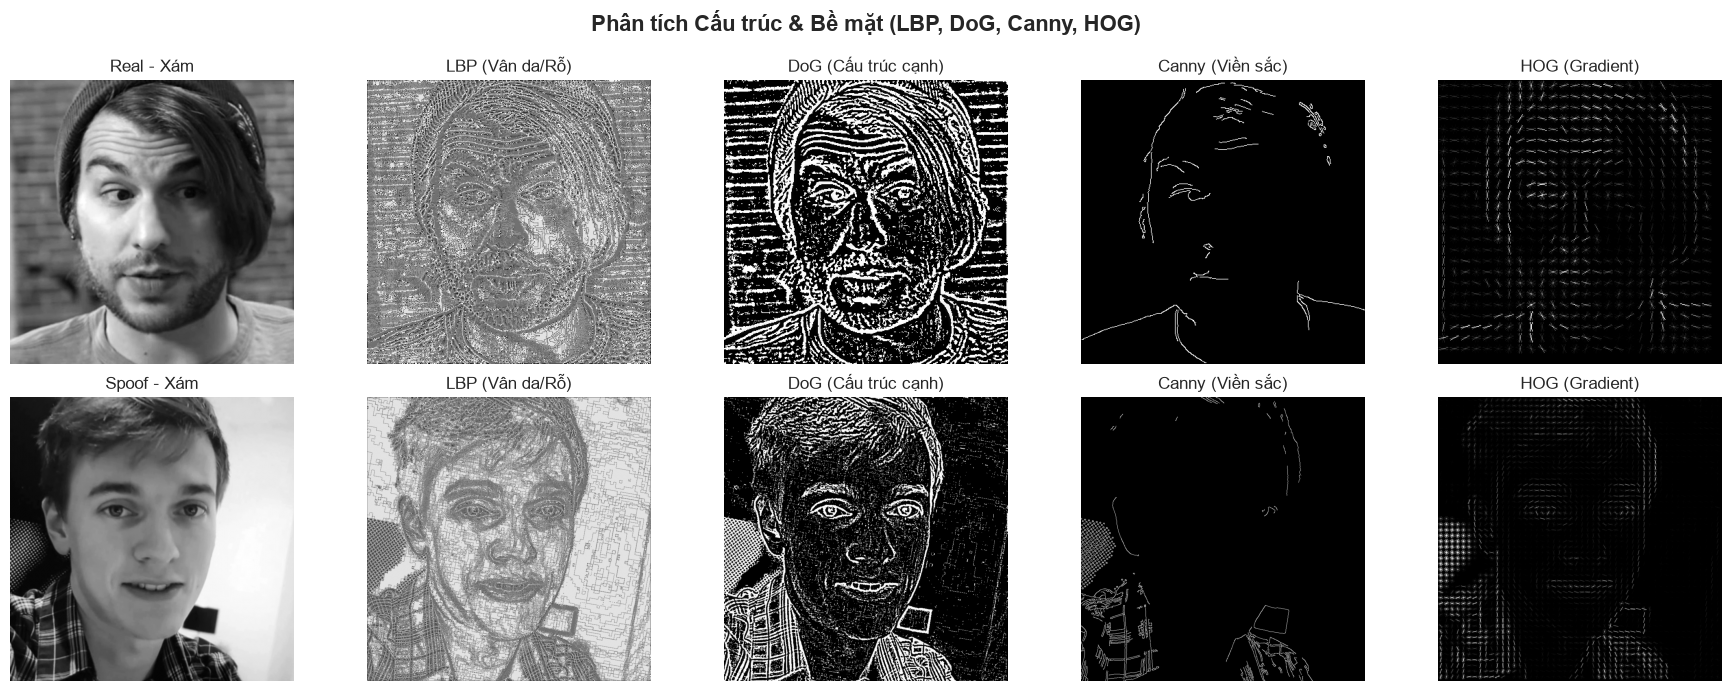

In [68]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Phân tích Cấu trúc & Bề mặt (LBP, DoG, Canny, HOG)", fontsize=16, fontweight='bold')

for i, (label, img_pil) in enumerate(samples):
    img_np = np.array(img_pil)
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    
    # 1. LBP
    lbp_map = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
    
    # 2. DoG (Difference of Gaussians)
    g1 = cv2.GaussianBlur(img_gray, (3, 3), 0)
    g2 = cv2.GaussianBlur(img_gray, (9, 9), 0)
    dog = g1 - g2
    
    # 3. Canny Edges
    edges = cv2.Canny(img_gray, 100, 200)
    
    # 4. HOG
    _, hog_img = hog(img_gray, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=True)
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    
    plots = [
        (img_gray, f"{label} - Xám"),
        (lbp_map, "LBP (Vân da/Rỗ)"),
        (dog, "DoG (Cấu trúc cạnh)"),
        (edges, "Canny (Viền sắc)"),
        (hog_img_rescaled, "HOG (Gradient)")
    ]
    
    for j, (img, title) in enumerate(plots):
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].set_title(title)
        axes[i, j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

---
### 4.3. Trích Xuất Nhiễu & Tần Số Chuyên Sâu (Noise & Frequency Analysis)

- **FFT (Fourier Transform):** Màn hình hay máy in hay tạo ra vân Moiré, sẽ xuất hiện dưới dạng các chấm sáng chói đối xứng trong phổ FFT.
- **SRM (Spatial Rich Model):** Bằng cách dùng các lõi lọc đặc biệt, SRM triệt tiêu toàn bộ khuôn mặt, chỉ chừa lại đúng vết xước màn hình, vệt nén JPEG, hay hạt mực.

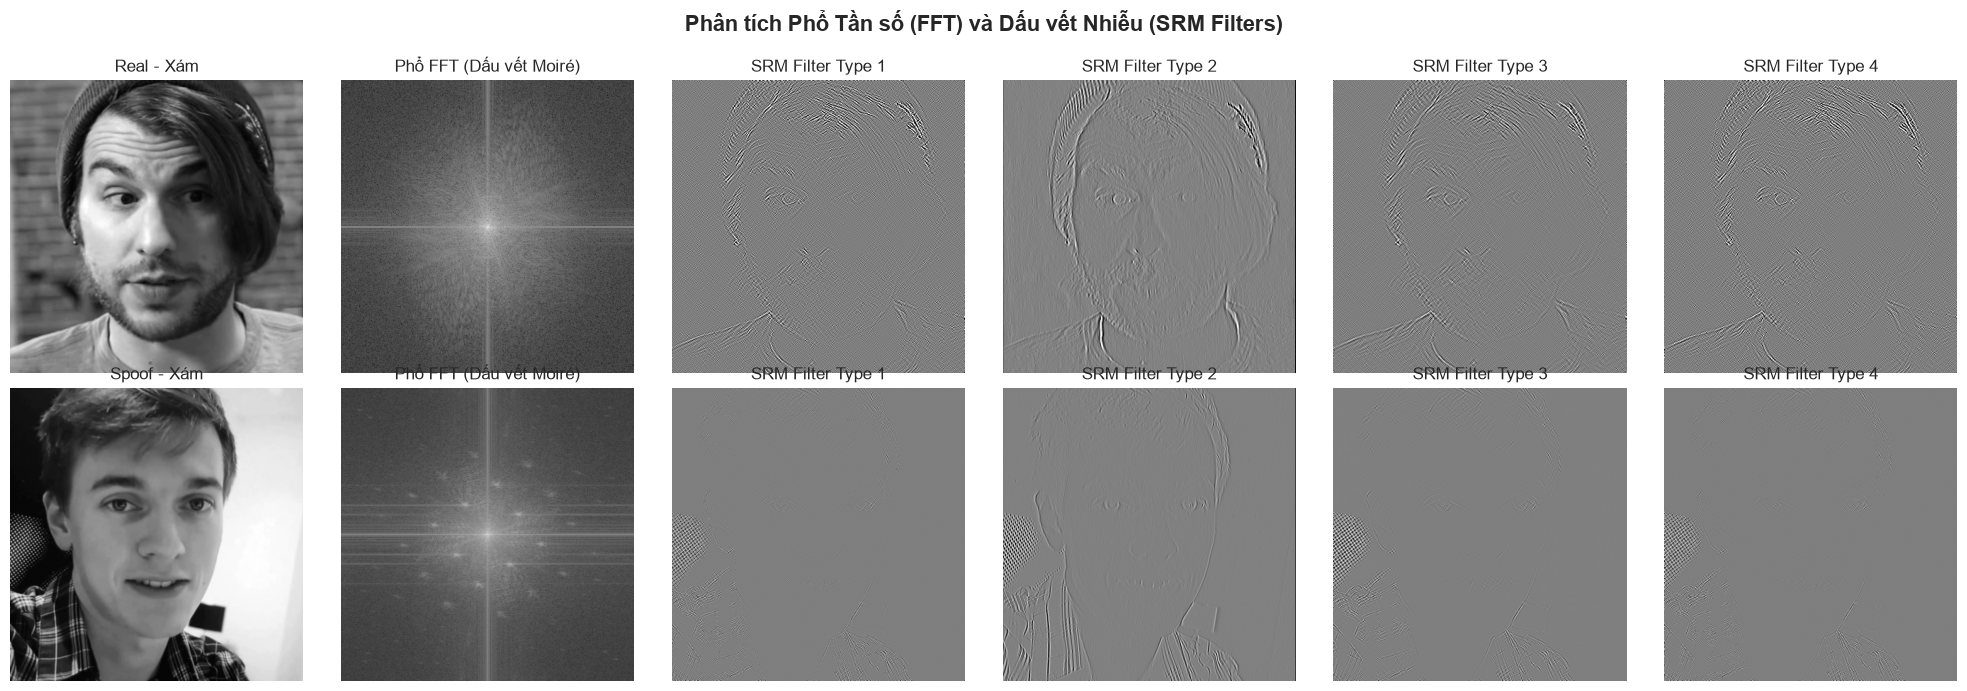

In [69]:
srm_transform = InputTransforms(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Phân tích Phổ Tần số (FFT) và Dấu vết Nhiễu (SRM Filters)", fontsize=16, fontweight='bold')

for i, (label, img_pil) in enumerate(samples):
    img_np = np.array(img_pil)
    img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    
    # FFT
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    fft_mag = 20 * np.log(np.abs(fshift) + 1)
    
    # SRM (Mô phỏng y hệt đường ống mạng Nơ-ron Artifact Branch)
    img_t = torch.tensor(img_np).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    img_t = (img_t - torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)) / torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
    _, noise = srm_transform(img_t)
    noise = noise.squeeze(0).numpy()
    
    plots = [
        (img_gray, f"{label} - Xám"),
        (fft_mag, "Phổ FFT (Dấu vết Moiré)")
    ]
    for j in range(4):
        n = noise[j * 2]
        m, s = n.mean(), n.std()
        n = np.clip(n, m - 3*s, m + 3*s) # Cắt bớt nhiễu biên (outliers) để tăng tương phản
        n_map = cv2.normalize(n, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        plots.append((n_map, f"SRM Filter Type {j+1}"))
        
    for j, (img, title) in enumerate(plots):
        axes[i, j].imshow(img, cmap='gray' if j > 0 else 'gray')
        axes[i, j].set_title(title)
        axes[i, j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

---
### 4.4. Ước Lượng Hình Học 3D (Monocular Depth Estimation)

Khuôn mặt thật có độ khối 3D. Màn hình điện thoại và ảnh in là mặt phẳng 2D. 
Tuy nhiên, lưu ý rằng các mạng CNN đánh giá chiều sâu (như **MiDaS**) thường hay bị "ảo giác ngữ nghĩa" (thấy hình mặt là đoán ra hình khối 3D dù đó là mặt phẳng), khiến kết quả trên ảnh crop sát đôi khi không đáng tin cậy.

Đang nạp mô hình MiDaS...


Using cache found in /home/dainguyen1506/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /home/dainguyen1506/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /home/dainguyen1506/.cache/torch/hub/intel-isl_MiDaS_master


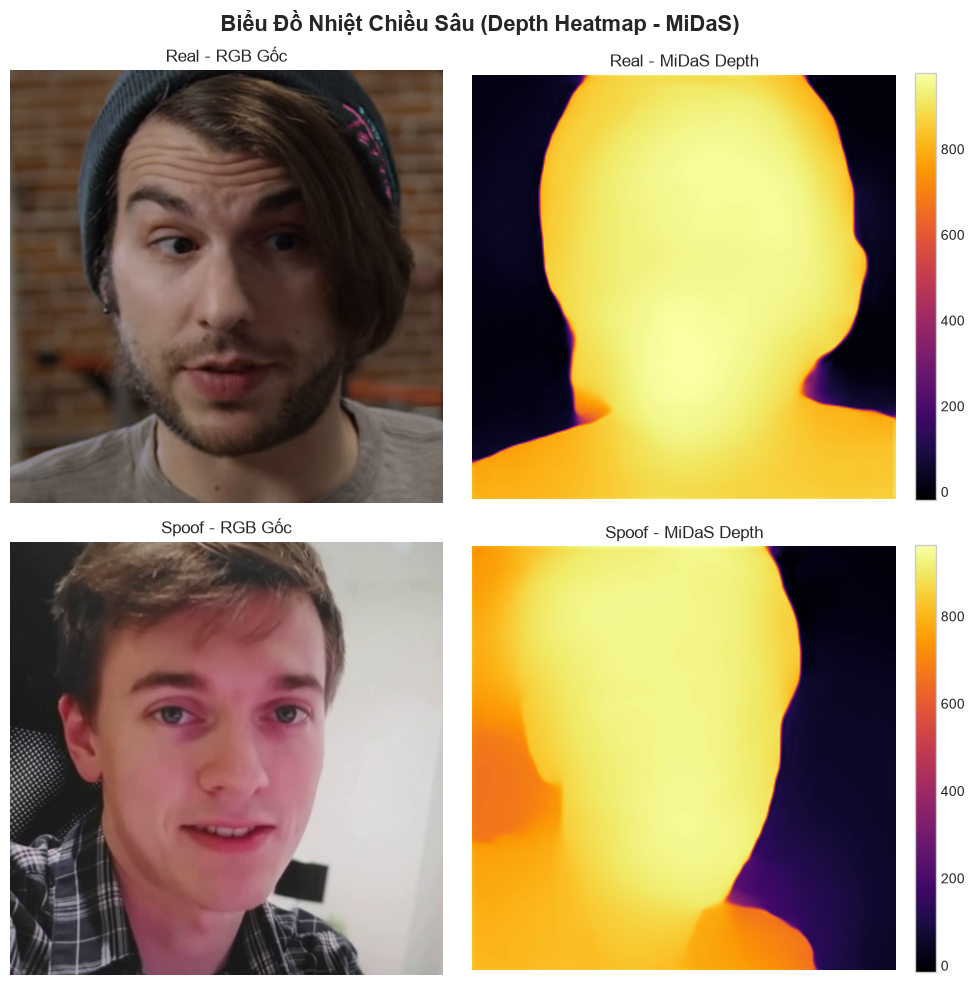

In [70]:
print("Đang nạp mô hình MiDaS...")
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", trust_repo=True)
midas.eval()
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms", trust_repo=True).small_transform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle("Biểu Đồ Nhiệt Chiều Sâu (Depth Heatmap - MiDaS)", fontsize=16, fontweight='bold')

for i, (label, img_pil) in enumerate(samples):
    img_np = np.array(img_pil)
    input_batch = midas_transforms(img_np).to(device)
    
    with torch.no_grad():
        prediction = midas(input_batch)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1), size=img_np.shape[:2], mode="bicubic", align_corners=False
        ).squeeze()
    
    depth_map = prediction.cpu().numpy()
    
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{label} - RGB Gốc")
    axes[i, 0].axis('off')
    
    img_plot = axes[i, 1].imshow(depth_map, cmap='inferno')
    axes[i, 1].set_title(f"{label} - MiDaS Depth")
    axes[i, 1].axis('off')
    fig.colorbar(img_plot, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

**Nhận xét:** Giả thuyết rằng tích hợp thêm đặc trưng 3D là sai lầm vì mô hình MiDas đã không thể chứng minh rằng chúng hữu ích trong việc trích xuất được đô sâu cửa bức ảnh giữa real và spoof.